# Diamond Price Prediction — Linear Regression

A baseline Linear Regression model predicting diamond prices from their physical and quality attributes.

**Dataset:** 53,940 diamonds (carat, cut, color, clarity, depth, table, dimensions, price)
**Goal:** predict `price` and evaluate how well a linear model captures the relationship between diamond attributes and price.

## Stage 1: Load, clean, and prep the data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('diamonds.csv')
print("Shape before cleaning:", df.shape)

# Drop rows with impossible zero dimensions (data quality issue found in EDA)
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print("Shape after cleaning:", df.shape)

# Encode ordinal categorical features (order matters — these are graded scales)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']  # J = worst, D = best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # I1 = worst, IF = best

df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True).codes
df['color'] = pd.Categorical(df['color'], categories=color_order, ordered=True).codes
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True).codes

df.head()

Shape before cleaning: (53940, 10)
Shape after cleaning: (53920, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


## Stage 2: Train/test split and baseline fit (all features)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

model = LinearRegression()
model.fit(X_train, y_train)

coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_}).sort_values('coefficient', ascending=False)
coef_df

Train shape: (43136, 9)
Test shape: (10784, 9)


,feature,coefficient
0,carat,10796.441095
3,clarity,499.478749
2,color,323.027896
7,y,134.964734
1,cut,128.290332
4,depth,-15.848311
5,table,-24.840495
6,x,-345.947877
8,z,-1093.661019


## Stage 3: Evaluate the baseline model

In [3]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R2:   {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")

R2:   0.9100
RMSE: $1,201.39
MAE:  $790.37


## Stage 4: Residual plot (baseline)

Checking whether errors are random (good) or patterned (a sign linear regression is missing something).

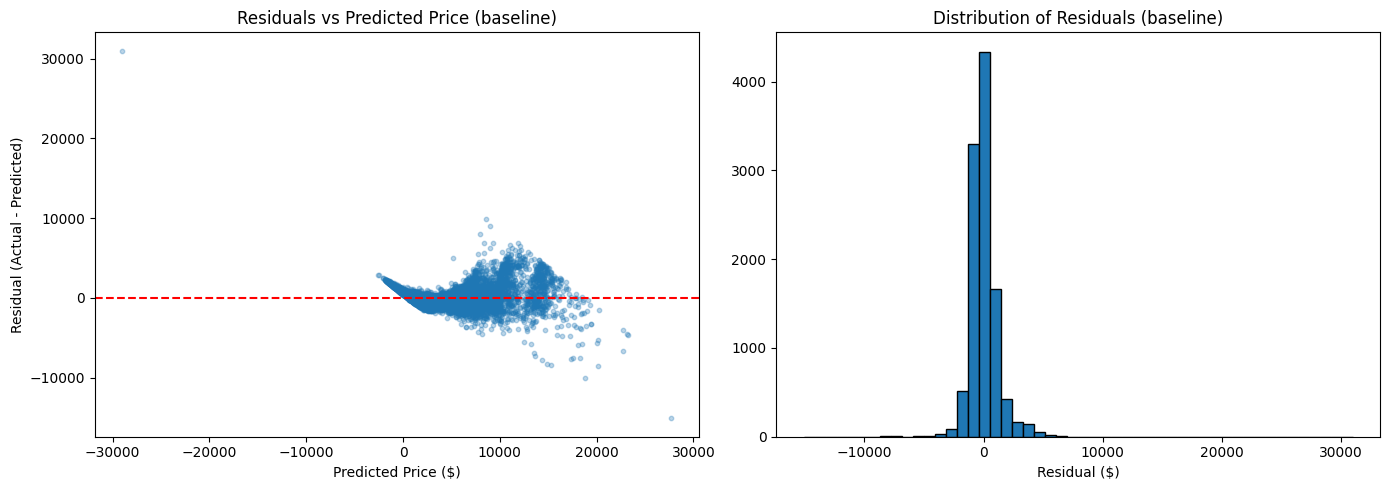

In [4]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Price (baseline)')

axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual ($)')
axes[1].set_title('Distribution of Residuals (baseline)')

plt.tight_layout()
plt.savefig('residual_plot_baseline.png', dpi=150)
plt.show()

**Finding:** one diamond has a predicted price of roughly –$30,000 — a nonsensical result. This points to multicollinearity: `carat`, `x`, `y`, and `z` are all highly correlated (they all measure diamond size), so the model assigns unstable weight across them.

## Stage 5: Fix — drop the redundant dimension columns (x, y, z)

In [5]:
X_train_v2 = X_train.drop(columns=['x', 'y', 'z'])
X_test_v2 = X_test.drop(columns=['x', 'y', 'z'])

model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train)

y_pred_v2 = model_v2.predict(X_test_v2)

r2_v2 = r2_score(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))
mae_v2 = mean_absolute_error(y_test, y_pred_v2)

print(f"R2:   {r2_v2:.4f}  (was {r2:.4f})")
print(f"RMSE: ${rmse_v2:,.2f}  (was ${rmse:,.2f})")
print(f"MAE:  ${mae_v2:,.2f}  (was ${mae:,.2f})")

coef_df_v2 = pd.DataFrame({'feature': X_train_v2.columns, 'coefficient': model_v2.coef_}).sort_values('coefficient', ascending=False)
coef_df_v2

R2:   0.9112  (was 0.9100)
RMSE: $1,193.23  (was $1,201.39)
MAE:  $839.65  (was $790.37)


,feature,coefficient
0,carat,8768.925481
3,clarity,519.074813
2,color,318.096076
1,cut,131.526334
5,table,-22.344092
4,depth,-40.686265


## Stage 6: Re-check the residual plot

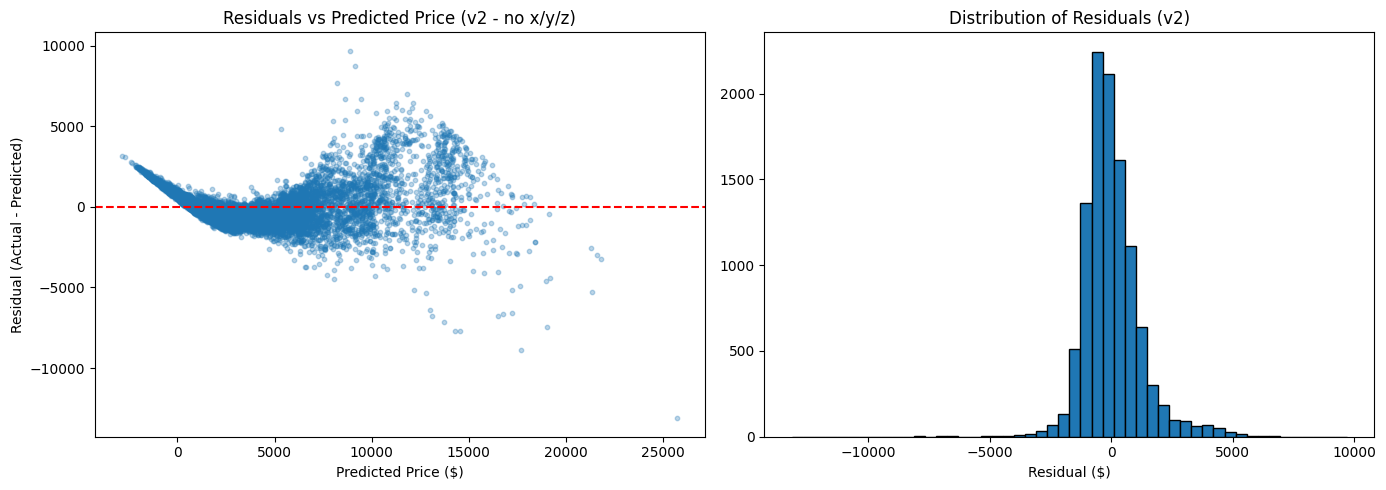

In [6]:
residuals_v2 = y_test - y_pred_v2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_v2, residuals_v2, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Price (v2 - no x/y/z)')

axes[1].hist(residuals_v2, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual ($)')
axes[1].set_title('Distribution of Residuals (v2)')

plt.tight_layout()
plt.savefig('residual_plot_v2.png', dpi=150)
plt.show()

## Summary

- **Dataset:** 53,940 diamonds -> 20 dropped for impossible zero dimensions
- **Final model:** Linear Regression on carat, cut, color, clarity, depth, table
- **Performance:** R2 = 0.9112, RMSE = $1,193, MAE = $840
- **Key decision:** dropped `x`, `y`, `z` (physical dimensions) due to multicollinearity with `carat` — improved both R2 and RMSE despite using fewer features, and fixed a nonsensical negative-price prediction outlier
- **Known limitation:** residuals show a funnel pattern (heteroscedasticity) — the model is less reliable for diamonds priced above ~$10,000. A log-transform of price, or a tree-based model (Random Forest / Gradient Boosting), would likely handle this better and is a natural next step.